# Spiking Diffusion for Audio (Exploratory Prototype)

This notebook explores a simple prototype combining **spiking neural networks (SNNs)** with a **diffusion-style denoising objective** for audio signals.

The goal is not to build a production speech generator, but to experiment with how **rate-coded spike trains** can be used with diffusion-style noise prediction.

Key components explored in this notebook:

- Rate coding for converting audio amplitudes into spike trains
- A spiking neural network denoiser implemented with snnTorch
- A simplified diffusion-style forward and reverse process
- Generation of a synthetic audio waveform from noise

## Motivation

Spiking neural networks (SNNs) are commonly used in neuromorphic computing because they process information using discrete spike events rather than continuous activations.

Diffusion models have recently become popular generative models, where a network learns to remove noise from progressively corrupted data.

This notebook explores a simple research question:

**Can spike-based neural networks be used to learn a diffusion-style denoising objective for audio signals?**

To investigate this idea, we construct a small prototype that:

1. Encodes audio amplitudes into spike trains using rate coding
2. Uses a spiking neural network to predict noise added to the signal
3. Iteratively applies a reverse process to generate a waveform from random noise

## Environment Setup

The implementation uses:

- **PyTorch** for tensor operations and optimization
- **snnTorch** for spiking neural network layers
- **NumPy** for signal processing
- **Matplotlib** for visualization
- **SoundFile** for exporting generated audio

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
from core.diffusion import SpikingDiffusion
from core.models import SpikingDenoiser

device = "cuda" if torch.cuda.is_available() else "cpu"


## Experiment Parameters

The following parameters define the audio length, diffusion steps, training duration, and spike simulation length.

In [2]:
# Parameters
# ===============================

L = 4000              # audio length
T = 50                # diffusion steps
num_steps = 25        # SNN time steps
epochs = 1000
sr = 16000

## Model Components

Two components are used in this prototype:

1. SpikingDiffusion  
   Handles the forward and reverse diffusion process.

2. SpikingDenoiser  
   A spiking neural network that predicts the noise added to the signal.

In [3]:
# Spiking Denoiser Network
model = SpikingDenoiser(input_dim=L, hidden_dim=1024).to(device)

diff = SpikingDiffusion()

## Synthetic Audio Signal

Instead of real speech, this experiment uses a simple synthetic waveform composed of multiple sine waves.

Frequencies used:
- 200 Hz
- 400 Hz
- 800 Hz

This creates a structured signal that can be used to test the denoising behavior of the model.

In [4]:
# Synthetic Speech Training Data
# ===============================

t = np.linspace(0, 1, sr)

audio = (
    0.5*np.sin(2*np.pi*200*t) +
    0.3*np.sin(2*np.pi*400*t) +
    0.2*np.sin(2*np.pi*800*t)
)

audio = audio / np.max(np.abs(audio))

waveform = torch.tensor(audio[:L]).float().to(device)

# normalize 0-1 for spike encoding
waveform = (waveform - waveform.min())/(waveform.max()-waveform.min())

## Training Procedure

During training:

1. A random diffusion timestep is selected.
2. Noise is added to the waveform.
3. The noisy waveform is encoded into spike trains using rate coding.
4. The spiking network predicts the added noise.
5. Mean squared error is used to train the model.

In [5]:
# Training
# ===============================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("Starting training...")

for epoch in range(epochs):

    t_step = torch.randint(0, T, (1,), device=device)

    noise = diff.poisson_noise(waveform)

    x_t = diff.q_sample(waveform, t_step, noise)

    spk = spikegen.rate(torch.clamp(x_t,0,1), num_steps=num_steps)
    
    pred_rate = model(spk, t_step)

    loss = loss_fn(pred_rate.squeeze(), waveform)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} Loss {loss.item():.4f}")

print("Training complete")

Starting training...
Epoch 0 Loss 0.2827
Epoch 100 Loss 0.0209
Epoch 200 Loss 0.0182
Epoch 300 Loss 0.0178
Epoch 400 Loss 0.0182
Epoch 500 Loss 0.0192
Epoch 600 Loss 0.0207
Epoch 700 Loss 0.0217
Epoch 800 Loss 0.0239
Epoch 900 Loss 0.0255
Training complete


## Reverse Diffusion Sampling

After training, a waveform can be generated by starting from random noise and iteratively applying the learned denoising process.

At each step the signal is spike-encoded and passed through the spiking denoiser network.

In [10]:
# Reverse Diffusion Sampling — NEW & BEST VERSION
# ===============================

model.eval()

x = torch.randn(1, L).to(device) * 0.5   # start from mild noise
x = torch.clamp(x, 0, 1)

for t in reversed(range(T)):          # ya 30-50 steps rakh
    spk = spikegen.rate(torch.clamp(x, 0, 1), num_steps=num_steps)
    
    rate = torch.relu(model(spk, torch.tensor([t]).to(device)))     # model abhi bhi rate predict kar raha hai
    
    # ================== YEHI MAGIC LINE ==================
    x = rate                          # ← Expected value of Poisson (mean)
    # ====================================================
    
    # Optional: thodi stochasticity chahiye toh (Poisson feel ke liye)
    # x = rate + (torch.poisson(rate) - rate) * 0.1   # centered Poisson noise

# Normalize final output
x = torch.clamp(x, 0, 1)

## Generated Waveform

The generated signal is saved as an audio file and plotted for visual inspection.

In [11]:
# Save Generated Audio
# ===============================

generated = x.squeeze().cpu().detach().numpy()

generated = generated / np.max(np.abs(generated))

sf.write("generated_speech.wav", generated, sr)

print("Generated speech saved!")


Generated speech saved!


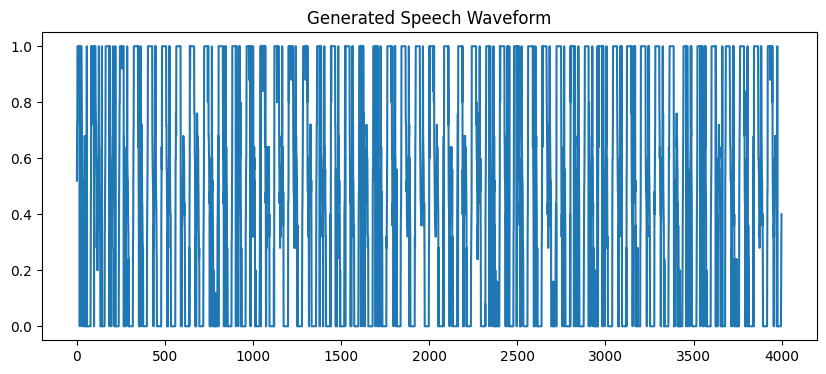

In [12]:
# Plot waveform
# ===============================

plt.figure(figsize=(10,4))
plt.plot(generated)
plt.title("Generated Speech Waveform")
plt.show()


## Signal Metrics

To summarize the generated waveform, several simple signal metrics are computed:

- Signal Power
- Waveform Variance
- Spectral Energy
- Zero Crossing Rate
- Spike Rate

In [13]:
# Metrics
# ===============================

print("----- Generation Metrics -----")

signal_power = np.mean(generated**2)
print("Signal Power:", signal_power)

variance = np.var(generated)
print("Waveform Variance:", variance)

fft = np.fft.fft(generated)
spectral_energy = np.mean(np.abs(fft))
print("Spectral Energy:", spectral_energy)

zcr = np.mean(np.abs(np.diff(np.sign(generated)))) / 2
print("Zero Crossing Rate:", zcr)

spk = spikegen.rate(torch.tensor(generated).unsqueeze(0).to(device), num_steps=num_steps)
spike_rate = torch.mean(spk.float()).item()

print("Average Spike Rate:", spike_rate)

----- Generation Metrics -----
Signal Power: 0.4144084
Waveform Variance: 0.1721377
Spectral Energy: 9.227779
Zero Crossing Rate: 0.050262567
Average Spike Rate: 0.49129998683929443


## Conclusion

In this notebook, we implemented a small experimental pipeline combining:

- rate-coded audio spike encoding
- a spiking neural network denoiser
- a simplified diffusion-style noise prediction objective

The model was trained on a synthetic waveform and then used to generate a signal by reversing the diffusion process.

While the generated signal is simple, the experiment illustrates how **spiking neural networks can be explored for generative modeling tasks** using diffusion-inspired training objectives.